In [1]:
import os
print(os.listdir('.'))

['UserAnimeList.csv', 'AnimeList.csv', 'anime_clean_filtered.csv', 'UserList.csv', '.DS_Store', 'users_filtered.csv', 'animelists_cleaned.csv', 'animelists_filtered.csv', '.ipynb_checkpoints', 'analyse_manga.ipynb', 'users_cleaned.csv', 'anime_clean.csv', 'anime_cleaned.csv', 'anime_filtered.csv']


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Chargement
df = pd.read_csv("anime_clean.csv")

# Premier aperçu
print("Dimensions :", df.shape)
print("\nColonnes :", df.columns.tolist())
df.head()

Dimensions : (14124, 15)

Colonnes : ['anime_id', 'title', 'type', 'source', 'episodes', 'status', 'score', 'scored_by', 'rank', 'popularity', 'members', 'favorites', 'premiered', 'studio', 'genre']


,anime_id,title,type,source,episodes,status,score,scored_by,rank,popularity,members,favorites,premiered,studio,genre
0,11013,Inu x Boku SS,TV,Manga,12,Finished Airing,7.63,139250,1274.0,231,283882,2809,Winter 2012,David Production,"Comedy, Supernatural, Romance, Shounen"
1,2104,Seto no Hanayome,TV,Manga,26,Finished Airing,7.89,91206,727.0,366,204003,2579,Spring 2007,Gonzo,"Comedy, Parody, Romance, School, Shounen"
2,5262,Shugo Chara!! Doki,TV,Manga,51,Finished Airing,7.55,37129,1508.0,1173,70127,802,Fall 2008,Satelight,"Comedy, Magic, School, Shoujo"
3,721,Princess Tutu,TV,Original,38,Finished Airing,8.21,36501,307.0,916,93312,3344,Summer 2002,Hal Film Maker,"Comedy, Drama, Magic, Romance, Fantasy"
4,12365,Bakuman. 3rd Season,TV,Manga,25,Finished Airing,8.67,107767,50.0,426,182765,2082,Fall 2012,J.C.Staff,"Comedy, Drama, Romance, Shounen"


In [3]:
# Infos générales sur le tableau
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14124 entries, 0 to 14123
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   anime_id    14124 non-null  int64  
 1   title       14124 non-null  object 
 2   type        14124 non-null  object 
 3   source      14124 non-null  object 
 4   episodes    14124 non-null  int64  
 5   status      14124 non-null  object 
 6   score       14124 non-null  float64
 7   scored_by   14124 non-null  int64  
 8   rank        12880 non-null  float64
 9   popularity  14124 non-null  int64  
 10  members     14124 non-null  int64  
 11  favorites   14124 non-null  int64  
 12  premiered   4021 non-null   object 
 13  studio      8381 non-null   object 
 14  genre       14068 non-null  object 
dtypes: float64(2), int64(6), object(7)
memory usage: 1.6+ MB


In [4]:
# Statistiques sur les colonnes numériques
df.describe()

,anime_id,episodes,score,scored_by,rank,popularity,members,favorites
count,14124.000000,14124.000000,14124.000000,1.412400e+04,12880.000000,14124.000000,1.412400e+04,14124.000000
mean,16906.932597,11.567686,6.296435,1.174725e+04,6436.489596,7219.870363,2.336168e+04,318.967502
std,12974.960763,43.950691,1.107942,4.360339e+04,3716.683608,4182.207270,7.581066e+04,2647.694018
min,1.000000,0.000000,1.000000,1.000000e+00,0.000000,0.000000,2.000000e+00,0.000000
25%,4162.750000,1.000000,5.630000,5.600000e+01,3217.750000,3580.000000,2.410000e+02,0.000000
50%,13834.000000,2.000000,6.400000,5.530000e+02,6437.500000,7224.000000,1.687000e+03,2.000000
75%,30561.000000,12.000000,7.080000,4.214500e+03,9650.500000,10858.250000,1.061175e+04,24.000000
max,37908.000000,1818.000000,10.000000,1.009477e+06,12919.000000,14487.000000,1.456378e+06,106895.000000


In [5]:
# On garde uniquement les colonnes intéressantes
colonnes_utiles = [
    'anime_id', 'title', 'type', 'source', 'episodes',
    'status', 'score', 'scored_by', 'rank', 'popularity',
    'members', 'favorites', 'premiered', 'studio', 'genre'
]

df_clean = df[colonnes_utiles].copy()

# On supprime les lignes avec un score de 0 (pas noté)
df_clean = df_clean[df_clean['score'] > 0]
df_clean = df_clean[~df_clean['genre'].str.contains('Hentai|Ecchi', na=False)]

print("Dimensions après nettoyage :", df_clean.shape)
df_clean.head()

Dimensions après nettoyage : (12237, 15)


,anime_id,title,type,source,episodes,status,score,scored_by,rank,popularity,members,favorites,premiered,studio,genre
0,11013,Inu x Boku SS,TV,Manga,12,Finished Airing,7.63,139250,1274.0,231,283882,2809,Winter 2012,David Production,"Comedy, Supernatural, Romance, Shounen"
1,2104,Seto no Hanayome,TV,Manga,26,Finished Airing,7.89,91206,727.0,366,204003,2579,Spring 2007,Gonzo,"Comedy, Parody, Romance, School, Shounen"
2,5262,Shugo Chara!! Doki,TV,Manga,51,Finished Airing,7.55,37129,1508.0,1173,70127,802,Fall 2008,Satelight,"Comedy, Magic, School, Shoujo"
3,721,Princess Tutu,TV,Original,38,Finished Airing,8.21,36501,307.0,916,93312,3344,Summer 2002,Hal Film Maker,"Comedy, Drama, Magic, Romance, Fantasy"
4,12365,Bakuman. 3rd Season,TV,Manga,25,Finished Airing,8.67,107767,50.0,426,182765,2082,Fall 2012,J.C.Staff,"Comedy, Drama, Romance, Shounen"


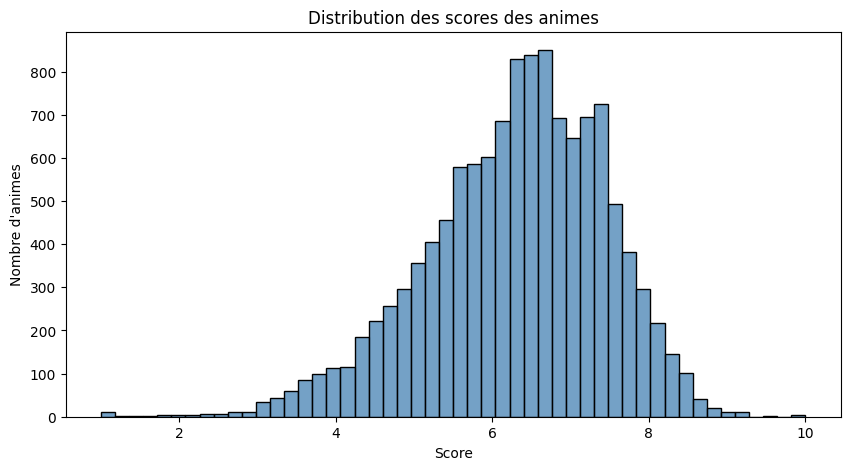

In [6]:
# Distribution des scores
plt.figure(figsize=(10, 5))
sns.histplot(df_clean['score'], bins=50, color='steelblue')
plt.title('Distribution des scores des animes')
plt.xlabel('Score')
plt.ylabel('Nombre d\'animes')
plt.show()

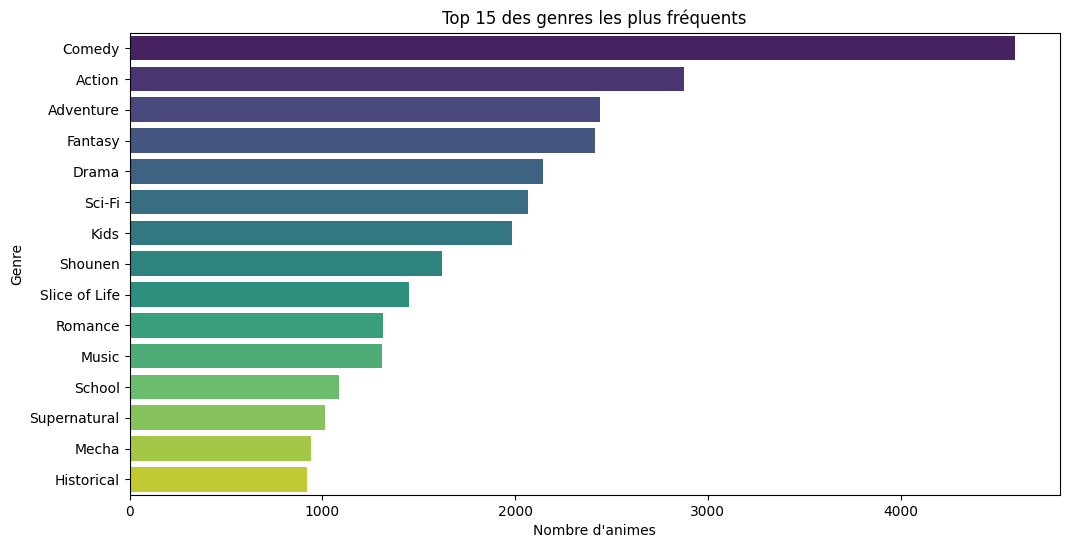

In [7]:
# La colonne genre contient plusieurs genres séparés par des virgules
# On doit les séparer et les compter individuellement
genres = df_clean['genre'].dropna().str.split(', ').explode()

# On compte les 15 genres les plus fréquents
top_genres = genres.value_counts().head(15)

# Graphique
plt.figure(figsize=(12, 6))
sns.barplot(x=top_genres.values, y=top_genres.index, hue=top_genres.index, palette='viridis', legend=False)
plt.title('Top 15 des genres les plus fréquents')
plt.xlabel('Nombre d\'animes')
plt.ylabel('Genre')
plt.show()

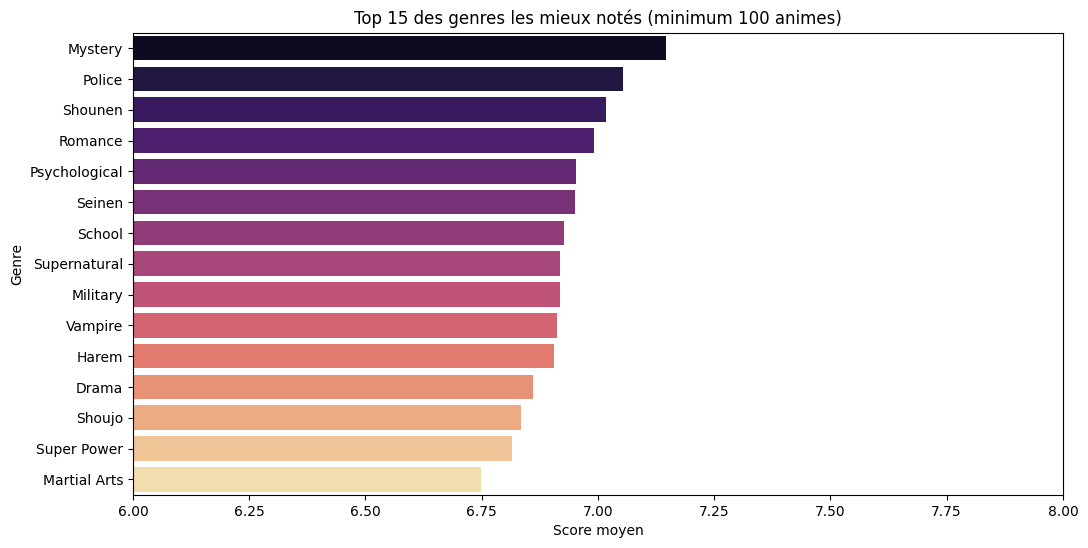

In [8]:
# On recrée un dataframe avec une ligne par genre
df_genres = df_clean.dropna(subset=['genre']).copy()
df_genres['genre'] = df_genres['genre'].str.split(', ')
df_genres = df_genres.explode('genre')

# Score moyen par genre (on garde les genres avec au moins 100 animes)
score_par_genre = df_genres.groupby('genre')['score'].agg(['mean', 'count'])
score_par_genre = score_par_genre[score_par_genre['count'] >= 100]
score_par_genre = score_par_genre.sort_values('mean', ascending=False).head(15)

# Graphique
plt.figure(figsize=(12, 6))
sns.barplot(x=score_par_genre['mean'], y=score_par_genre.index, 
            hue=score_par_genre.index, palette='magma', legend=False)
plt.title('Top 15 des genres les mieux notés (minimum 100 animes)')
plt.xlabel('Score moyen')
plt.ylabel('Genre')
plt.xlim(6, 8)
plt.show()

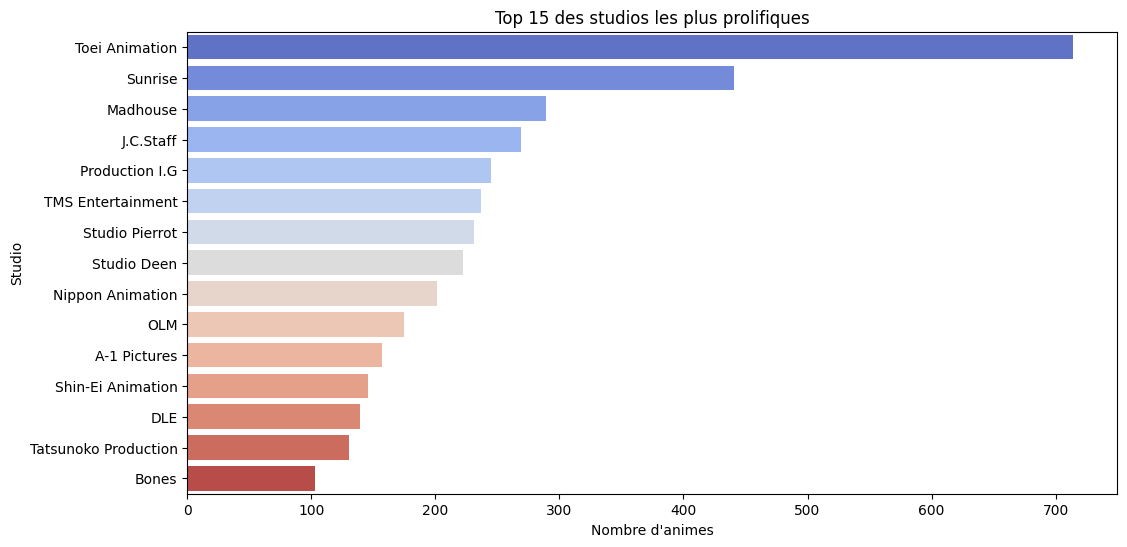

In [9]:
# On compte le nombre d'animes par studio
top_studios = df_clean.dropna(subset=['studio'])
top_studios = top_studios['studio'].value_counts().head(15)

# Graphique
plt.figure(figsize=(12, 6))
sns.barplot(x=top_studios.values, y=top_studios.index,
            hue=top_studios.index, palette='coolwarm', legend=False)
plt.title('Top 15 des studios les plus prolifiques')
plt.xlabel('Nombre d\'animes')
plt.ylabel('Studio')
plt.show()

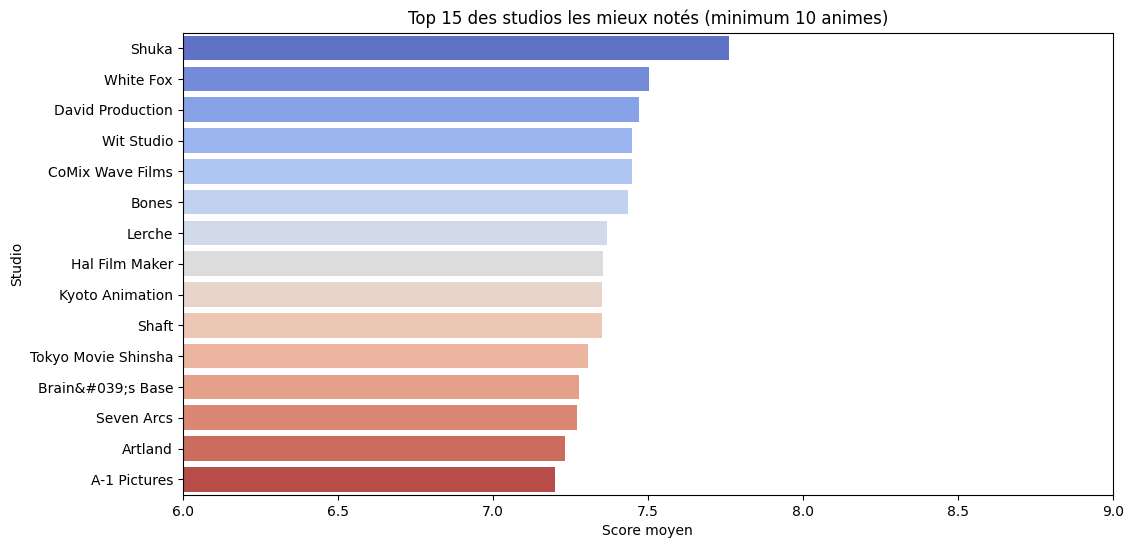

In [10]:
# Score moyen par studio (minimum 10 animes pour être représentatif)
score_par_studio = df_clean.dropna(subset=['studio']).groupby('studio')['score'].agg(['mean', 'count'])
score_par_studio = score_par_studio[score_par_studio['count'] >= 10]
score_par_studio = score_par_studio.sort_values('mean', ascending=False).head(15)

# Graphique
plt.figure(figsize=(12, 6))
sns.barplot(x=score_par_studio['mean'], y=score_par_studio.index,
            hue=score_par_studio.index, palette='coolwarm', legend=False)
plt.title('Top 15 des studios les mieux notés (minimum 10 animes)')
plt.xlabel('Score moyen')
plt.ylabel('Studio')
plt.xlim(6, 9)
plt.show()

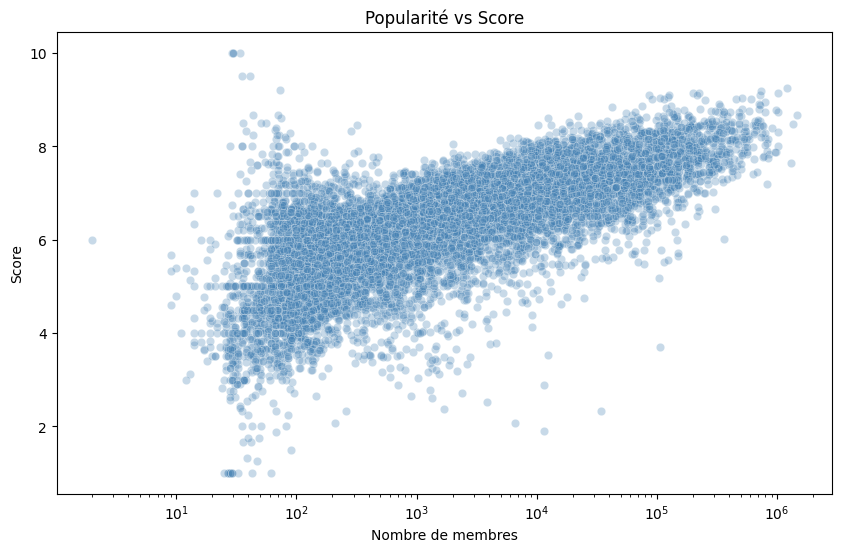

In [11]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_clean, x='members', y='score', alpha=0.3, color='steelblue')
plt.title('Popularité vs Score')
plt.xlabel('Nombre de membres')
plt.ylabel('Score')
plt.xscale('log') # échelle logarithmique car les valeurs sont très étalées
plt.show()

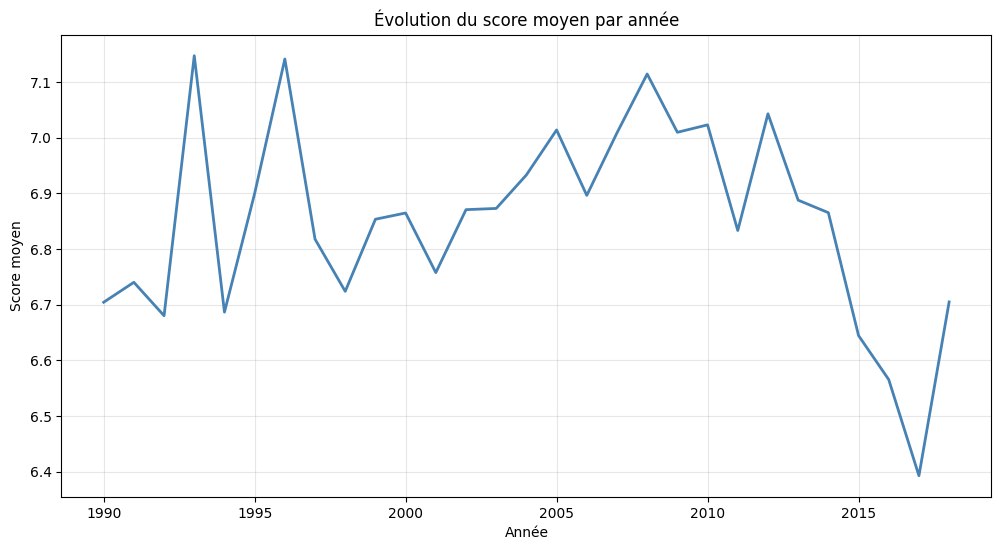

In [12]:
# On extrait l'année depuis la colonne premiered
df_time = df_clean.dropna(subset=['premiered']).copy()

# La colonne premiered ressemble à "Spring 2012" - on extrait juste l'année
df_time['year'] = df_time['premiered'].str.extract(r'(\d{4})')
df_time['year'] = pd.to_numeric(df_time['year'])

# On garde les années entre 1990 et 2018
df_time = df_time[(df_time['year'] >= 1990) & (df_time['year'] <= 2018)]

# Score moyen par année
score_par_annee = df_time.groupby('year')['score'].mean()

# Graphique
plt.figure(figsize=(12, 6))
plt.plot(score_par_annee.index, score_par_annee.values, color='steelblue', linewidth=2)
plt.title('Évolution du score moyen par année')
plt.xlabel('Année')
plt.ylabel('Score moyen')
plt.grid(True, alpha=0.3)
plt.show()

In [13]:
# On exporte le tableau nettoyé
df_clean.to_csv('anime_clean.csv', index=False)
print("Fichier exporté !")

Fichier exporté !
